<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelima/blob/main/Praktikum_5_1_MG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 5.1: IMPLEMENTASI KONVOLUSI MANUAL
Identity kernel applied successfully
Mean 3x3 kernel applied successfully
Sharpen kernel applied successfully
Edge Detection kernel applied successfully
Gaussian 3x3 kernel applied successfully


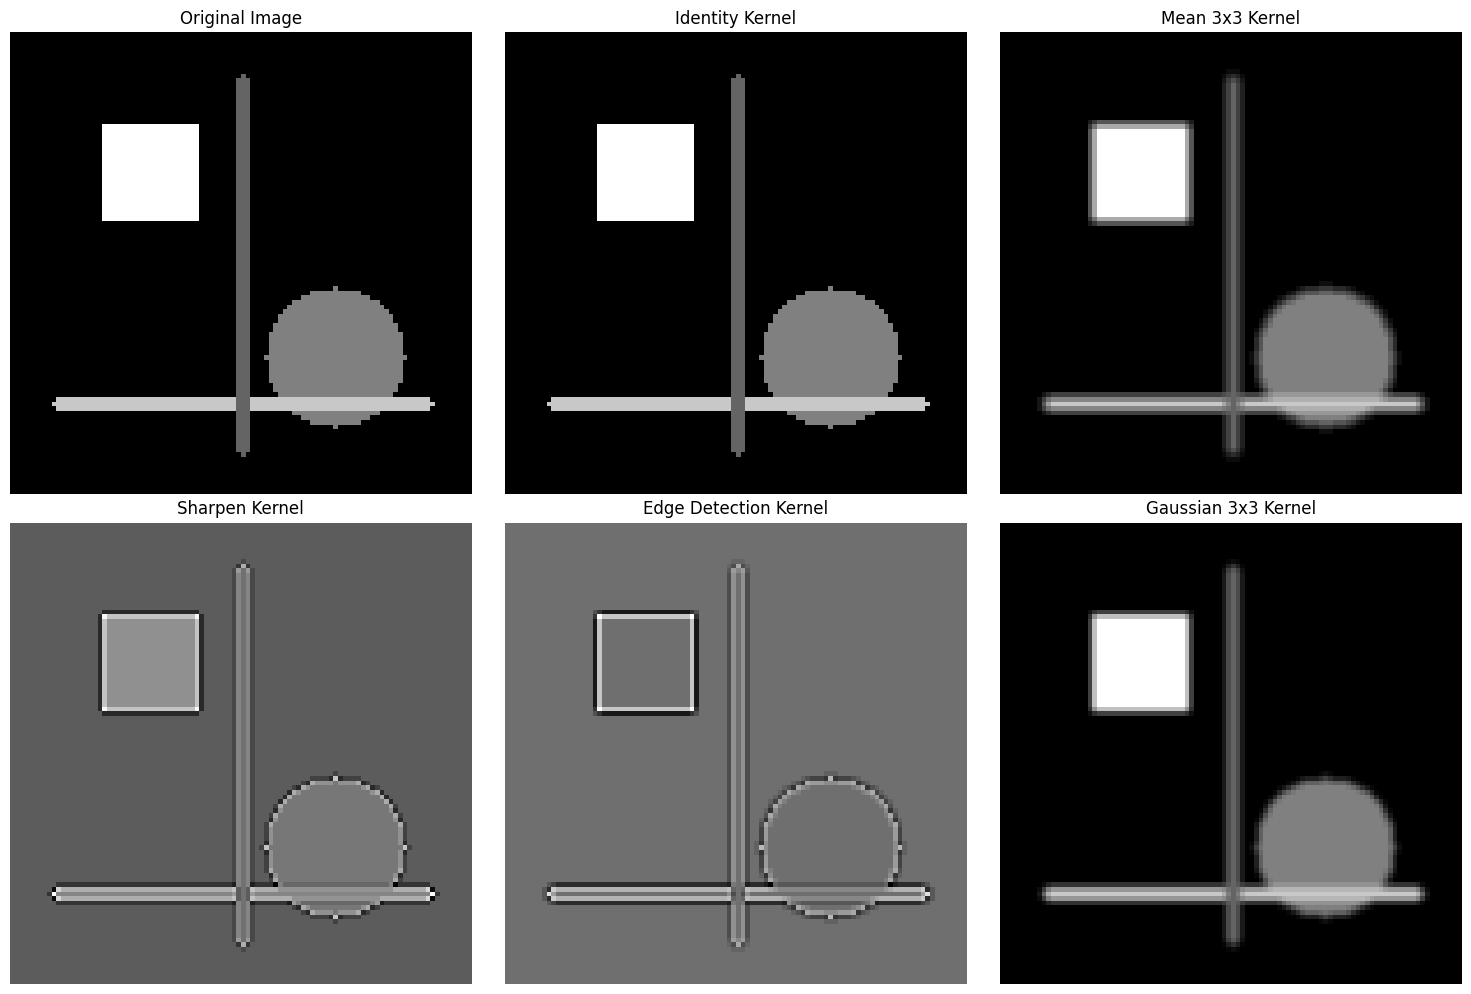

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def manual_convolution(image, kernel):
    """
    Implementasi manual operasi konvolusi
    """
    # Dapatkan dimensi
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Hitung padding
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    # Buat image dengan zero padding
    padded_img = np.zeros((img_h + 2*pad_h, img_w + 2*pad_w))
    padded_img[pad_h:pad_h+img_h, pad_w:pad_w+img_w] = image

    # Inisialisasi output
    output = np.zeros_like(image, dtype=np.float32)

    # Lakukan konvolusi
    for i in range(img_h):
        for j in range(img_w):
            # Ambil region of interest
            region = padded_img[i:i+kernel_h, j:j+kernel_w]
            # Hitung sum of product
            output[i, j] = np.sum(region * kernel)

    return output

# Membuat citra test pattern
def create_test_pattern(size=100):
    """Membuat citra test pattern dengan edge yang jelas"""
    img = np.zeros((size, size), dtype=np.float32)

    # Add different patterns
    cv2.rectangle(img, (20, 20), (40, 40), 255, -1)  # White square
    cv2.circle(img, (70, 70), 15, 128, -1)  # Gray circle
    cv2.line(img, (10, 80), (90, 80), 200, 2)  # Horizontal line
    cv2.line(img, (50, 10), (50, 90), 100, 2)  # Vertical line

    return img

# Define different kernels
kernels = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]]),

    'Mean 3x3': np.array([[1, 1, 1],
                          [1, 1, 1],
                          [1, 1, 1]]) / 9,

    'Sharpen': np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    'Edge Detection': np.array([[-1, -1, -1],
                                [-1, 8, -1],
                                [-1, -1, -1]]),

    'Gaussian 3x3': np.array([[1, 2, 1],
                              [2, 4, 2],
                              [1, 2, 1]]) / 16
}

# Praktikum konvolusi
print("PRAKTIKUM 5.1: IMPLEMENTASI KONVOLUSI MANUAL")
print("=" * 50)

# Create test image
test_image = create_test_pattern(100)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Original image
axes[0].imshow(test_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply each kernel
for idx, (kernel_name, kernel) in enumerate(list(kernels.items())[:5]):
    result = manual_convolution(test_image, kernel)

    axes[idx+1].imshow(result, cmap='gray')
    axes[idx+1].set_title(f'{kernel_name} Kernel')
    axes[idx+1].axis('off')

    print(f"{kernel_name} kernel applied successfully")

plt.tight_layout()
plt.show()